# Notebook 1: eda on the clinical csv

**exploratory data analysis**: 
we check:
**class balance** (cdr visits) 
**missingness**
**linear association** (pearson correlation) between each numeric column and cdr. 


cdr **2** is dropped so everything lines up with a three-level label set **0 / 0.5 / 1** that the hmm uses later.

## Columns

**`cdr`** (clinical dementia rating) is the outcome people usually predict: **0** none, **0.5** very mild / questionable, **1** mild

**ids & study design**: `subject id` is the person; `mri id` is one scan; `group` is nondemented / demented / converted (related to cdr but not the same); `visit` counts timepoints and `mr delay` is days from baseline.

**demographics**: `age`, `educ`, `ses`, `m/f`, `hand`.

**cognitive & structural**: `mmse` is cognition (0:30, lower is worse); `etiv` is estimated intracranial volume; `nwbv` is normalized whole-brain volume; `asf` scales for head size.

**`sex_male`** below is just `m/f` coded as 1 for m so it can sit in the correlation matrix with the other numbers.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)

# load the clinical csv
df_raw = pd.read_csv("../data/clinical.csv")
print("Raw shape:", df_raw.shape)

Raw shape: (373, 15)


In [16]:
# drop cdr==2 so labels stay 0 / 0.5 / 1
n_drop = int((df_raw["CDR"] == 2).sum())
df = df_raw.loc[df_raw["CDR"] != 2].copy().reset_index(drop=True)
print(f"Excluded CDR=2 visits: {n_drop} | Rows after filter: {len(df)}")
df["Sex_male"] = (df["M/F"] == "M").astype(float)


Excluded CDR=2 visits: 3 | Rows after filter: 370


In [17]:
# dtypes and missing counts
print(df.dtypes)
print("\nMissing per column:")
print(df.isna().sum().sort_values(ascending=False))
print("\nCDR value counts (visit level):")
print(df["CDR"].value_counts().sort_index())
print("\nGroup (visit level):")
print(df["Group"].value_counts())
print(f"\nUnique subjects: {df['Subject ID'].nunique()}")


Subject ID        str
MRI ID            str
Group             str
Visit           int64
MR Delay        int64
M/F               str
Hand              str
Age             int64
EDUC            int64
SES           float64
MMSE          float64
CDR           float64
eTIV            int64
nWBV          float64
ASF           float64
Sex_male      float64
dtype: object

Missing per column:
SES           19
MMSE           2
Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
CDR            0
eTIV           0
nWBV           0
ASF            0
Sex_male       0
dtype: int64

CDR value counts (visit level):
CDR
0.0    206
0.5    123
1.0     41
Name: count, dtype: int64

Group (visit level):
Group
Nondemented    190
Demented       143
Converted       37
Name: count, dtype: int64

Unique subjects: 150


Correlation with CDR (Pearson r):
MMSE       -0.6901
nWBV       -0.3555
Sex_male    0.2305
EDUC       -0.2032
SES         0.1161
MR Delay   -0.0721
Age        -0.0721
ASF        -0.0185
eTIV        0.0135
Visit      -0.0027


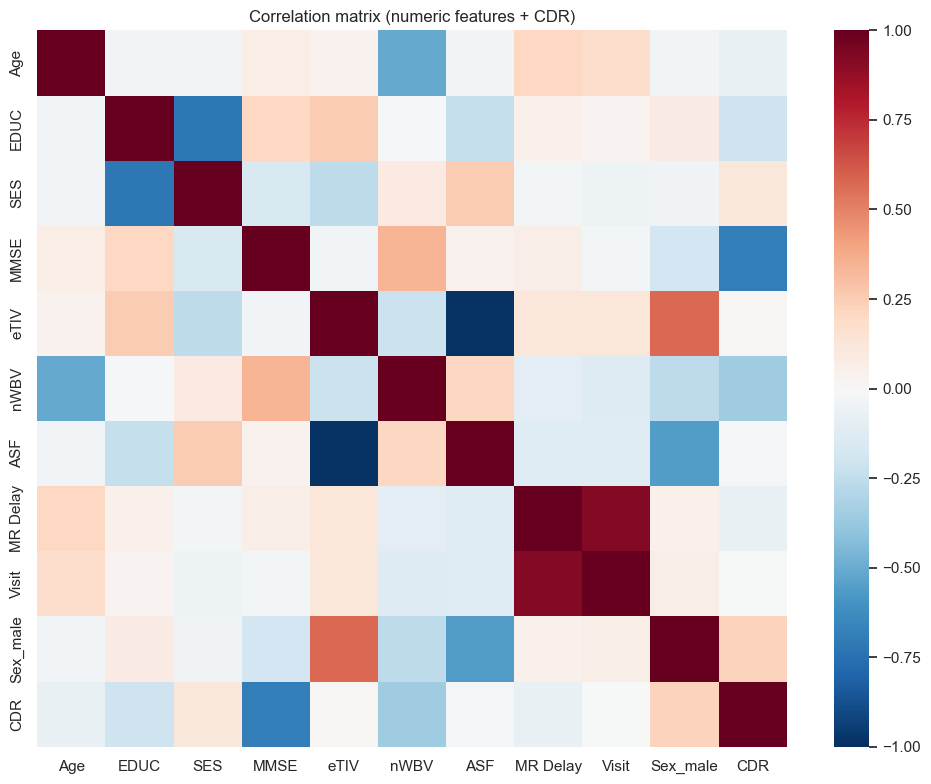

In [18]:
# pearson r vs cdr for numeric columns (includes sex_male)
num_cols = [
 "Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF",
 "MR Delay", "Visit", "Sex_male", "CDR",
]
num_cols = [c for c in num_cols if c in df.columns]
corr_with_cdr = df[num_cols].corr(numeric_only=True)["CDR"].drop("CDR").sort_values(key=abs, ascending=False)
print("Correlation with CDR (Pearson r):")
print(corr_with_cdr.round(4).to_string())

# full numeric correlation heatmap (pairwise complete)
cmat = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(cmat, annot=False, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (numeric features + CDR)")
plt.tight_layout()
plt.show()


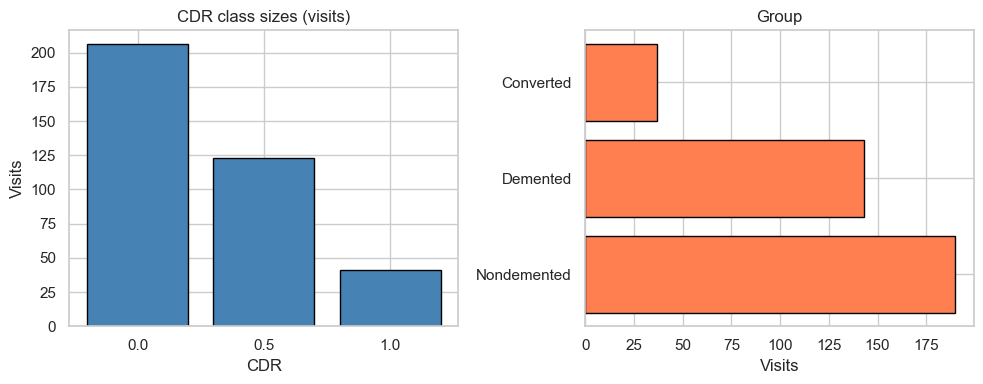

In [19]:
# cdr and group visit counts
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cdr_vc = df["CDR"].value_counts().sort_index()
axes[0].bar(cdr_vc.index.astype(str), cdr_vc.values, color="steelblue", edgecolor="black")
axes[0].set_xlabel("CDR")
axes[0].set_ylabel("Visits")
axes[0].set_title("CDR class sizes (visits)")

gvc = df["Group"].value_counts()
axes[1].barh(gvc.index, gvc.values, color="coral", edgecolor="black")
axes[1].set_xlabel("Visits")
axes[1].set_title("Group")
plt.tight_layout()
plt.show()


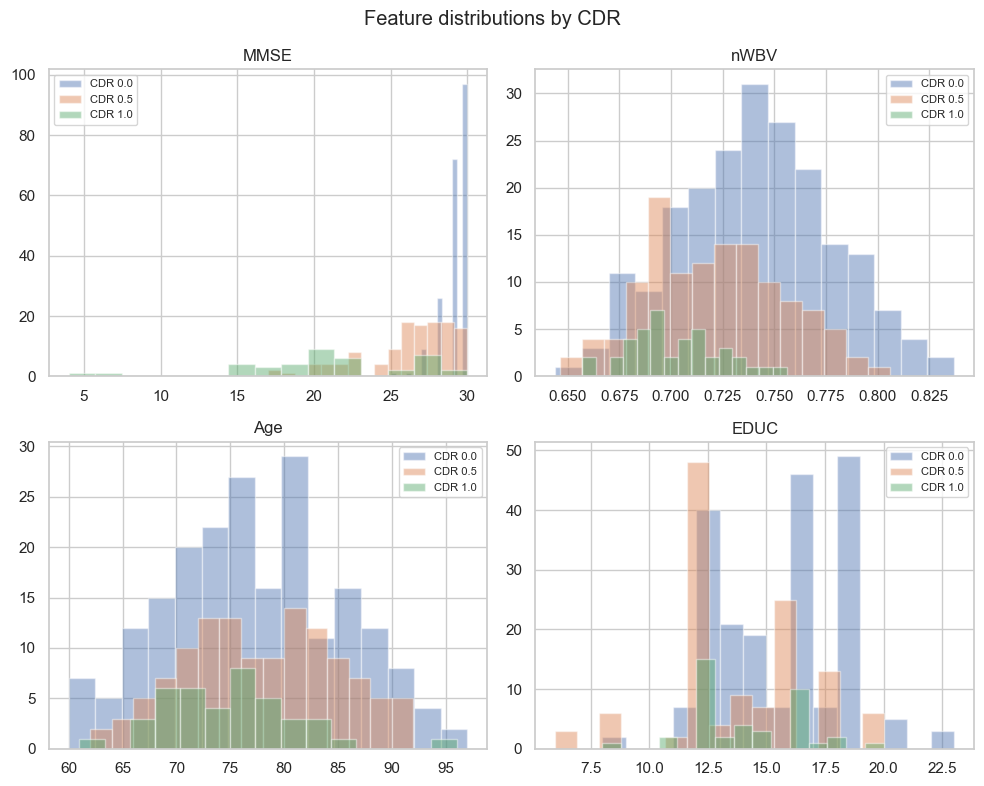

In [20]:
# histograms of a few continuous vars by cdr
feat_hist = ["MMSE", "nWBV", "Age", "EDUC"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for ax, col in zip(axes, feat_hist):
 for cdr in sorted(df["CDR"].unique()):
   subset = df.loc[df["CDR"] == cdr, col].dropna()
   ax.hist(subset, alpha=0.45, label=f"CDR {cdr}", bins=15)
   ax.set_title(col)
   ax.legend(fontsize=8)
plt.suptitle("Feature distributions by CDR")
plt.tight_layout()
plt.show()


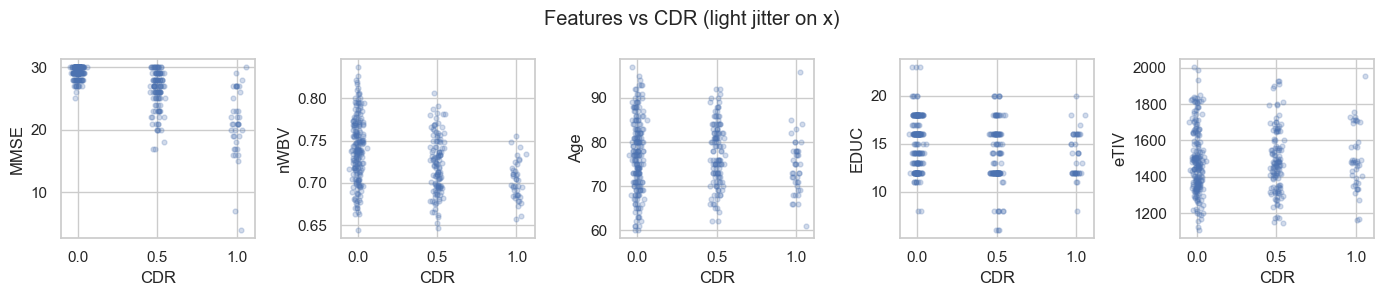

In [21]:
# scatter vs cdr (light jitter on x)
plot_cols = ["MMSE", "nWBV", "Age", "EDUC", "eTIV"]
fig, axes = plt.subplots(1, len(plot_cols), figsize=(14, 3), sharey=False)
for ax, col in zip(axes, plot_cols):
 jitter = np.random.default_rng(42).normal(0, 0.02, size=len(df))
 ax.scatter(df["CDR"].astype(float) + jitter, df[col], alpha=0.25, s=12)
 ax.set_xlabel("CDR")
 ax.set_ylabel(col)
 ax.set_xticks([0, 0.5, 1])
plt.suptitle("Features vs CDR (light jitter on x)")
plt.tight_layout()
plt.show()


## Takeaways

After dropping cdr 2, visit counts are usually **imbalanced** toward cdr 0: typical in clinical tables. **imbalance** matters: accuracy can look fine while rare classes (cdr 1) are ignored; notebook 2 reports **macro f1** and **balanced** metrics partly for that reason.

correlations: **mmse** usually tracks cdr strongly; **nwbv** often reflects brain decay; **educ** / **sex** are usually weaker: that's **feature relevance**, not causation.

notebook 2 turns these columns into **per-subject time series** and fits an hmm; notebook 4 can swap in **cnn/mri embedding** columns from colab.

cdr **2** stays out because there aren't enough rows for a stable fourth class.